<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>


# Test Environment for Generative AI classroom labs

This lab provides a test environment for the codes generated using the Generative AI classroom.

Follow the instructions below to set up this environment for further use.


# Setup


### Install required libraries

In case of a requirement of installing certain python libraries for use in your task, you may do so as shown below.


In [1]:
%pip install seaborn
import piplite

await piplite.install(['nbformat', 'plotly'])

### Dataset URL from the GenAI lab
Use the URL provided in the GenAI lab in the cell below. 


In [2]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0271EN-SkillsNetwork/labs/v1/m3/data/used_car_price_analysis.csv"


### Downloading the dataset

Execute the following code to download the dataset in to the interface.

> Please note that this step is essential in JupyterLite. If you are using a downloaded version of this notebook and running it on JupyterLabs, then you can skip this step and directly use the URL in pandas.read_csv() function to read the dataset as a dataframe


In [3]:
from pyodide.http import pyfetch

async def download(url, filename):
    response = await pyfetch(url)
    if response.status == 200:
        with open(filename, "wb") as f:
            f.write(await response.bytes())

path = URL

await download(path, "dataset.csv")
file_name  = "dataset.csv"

---


# Test Environment


In [4]:
import pandas as pd

def load_csv_and_show_head(file_path: str) -> pd.DataFrame:
    # Read CSV with the first row as header (header=0 is default)
    df = pd.read_csv(file_path, header=0)
    # Print the first 5 rows for verification
    print(df.head())
    return df

if __name__ == "__main__":
    # Replace with your actual file path
    file_path = "dataset.csv"
    load_csv_and_show_head(file_path)

<ipython-input-4-69fc5329e652>:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


     model  year transmission  mileage fuelType    tax   mpg  engineSize  \
0   Fiesta  2017    Automatic    15944   Petrol  150.0  57.7         1.0   
1    Focus  2018       Manual     9083   Petrol  150.0  57.7         1.0   
2    Focus  2017       Manual    12456   Petrol  150.0  57.7         1.0   
3   Fiesta  2019       Manual    10460   Petrol  145.0  40.3         1.5   
4   Fiesta  2019    Automatic     1482   Petrol  145.0  48.7         1.0   

   price  
0  12000  
1  14000  
2  13000  
3  17500  
4  16500  


In [6]:
def clean_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    # 1. Identify columns with missing values
    missing_cols = df.columns[df.isnull().any()].tolist()
    print("Columns with missing values:", missing_cols)

    # 2. Replace missing values with mean for numeric columns
    for col in missing_cols:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].mean())
        else:
            # Non-numeric columns: skip mean imputation (could optionally fill with mode)
            print(f"Warning: Non-numeric column '{col}' cannot be filled with mean. Skipping.")

    # 3. Delete duplicate entries
    df = df.drop_duplicates()

    return df

# Example usage:
df = pd.read_csv("dataset.csv")
df = clean_dataframe(df)
print(df.head())

Columns with missing values: ['tax']
     model  year transmission  mileage fuelType    tax   mpg  engineSize  \
0   Fiesta  2017    Automatic    15944   Petrol  150.0  57.7         1.0   
1    Focus  2018       Manual     9083   Petrol  150.0  57.7         1.0   
2    Focus  2017       Manual    12456   Petrol  150.0  57.7         1.0   
3   Fiesta  2019       Manual    10460   Petrol  145.0  40.3         1.5   
4   Fiesta  2019    Automatic     1482   Petrol  145.0  48.7         1.0   

   price  
0  12000  
1  14000  
2  13000  
3  17500  
4  16500  


In [8]:
import numpy as np

def top_n_correlated_features(df: pd.DataFrame, target_col: str, top_n: int = 5, method: str = 'pearson') -> pd.DataFrame:
    if method not in {'pearson', 'spearman', 'kendall'}:
        raise ValueError("method must be 'pearson', 'spearman', or 'kendall'")

    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found in DataFrame.")

    # Work with numeric columns for correlation
    numeric_df = df.select_dtypes(include=[np.number])
    if target_col not in numeric_df.columns:
        raise ValueError(f"Target column '{target_col}' is not numeric and cannot be used for correlation.")

    # Compute correlation matrix
    corr = numeric_df.corr(method=method)

    # Correlations with the target (excluding self)
    target_corr = corr[target_col].drop(index=target_col, errors='ignore')

    # Absolute value to measure strength, then sort descending
    top_series = target_corr.abs().sort_values(ascending=False).head(top_n)

    # Return as a small DataFrame: feature and its correlation with target
    return pd.DataFrame({'feature': top_series.index, 'correlation': top_series.values})

# Example usage:
df = pd.read_csv("dataset.csv")
top5 = top_n_correlated_features(df, target_col='price', top_n=5, method='pearson')
print(top5)

      feature  correlation
0        year     0.636009
1     mileage     0.530659
2  engineSize     0.411178
3         tax     0.406895
4         mpg     0.346419


In [9]:
def count_unique_values(df: pd.DataFrame, column: str, include_nan: bool = False) -> pd.DataFrame:
    """
    Count occurrences of each unique value in a given column.

    Parameters:
    - df: input DataFrame
    - column: column name to analyze
    - include_nan: if True, include NaN as a separate category

    Returns:
    - DataFrame with columns [column, 'count'] sorted by count descending
    """
    if column not in df.columns:
        raise ValueError(f"Column '{column}' not found in DataFrame.")

    counts = df[column].value_counts(dropna=not include_nan)
    result = counts.reset_index()
    result.columns = [column, 'count']
    return result

# Example usage:
df = pd.read_csv("dataset.csv")
counts_df = count_unique_values(df, column='fuelType', include_nan=True)
print(counts_df)

   fuelType  count
0    Petrol  12179
1    Diesel   5762
2    Hybrid     22
3  Electric      2
4     Other      1


<ipython-input-19-4b365b89ffc5>:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=x_col, y=target_attr, data=plot_df, palette="Set3")


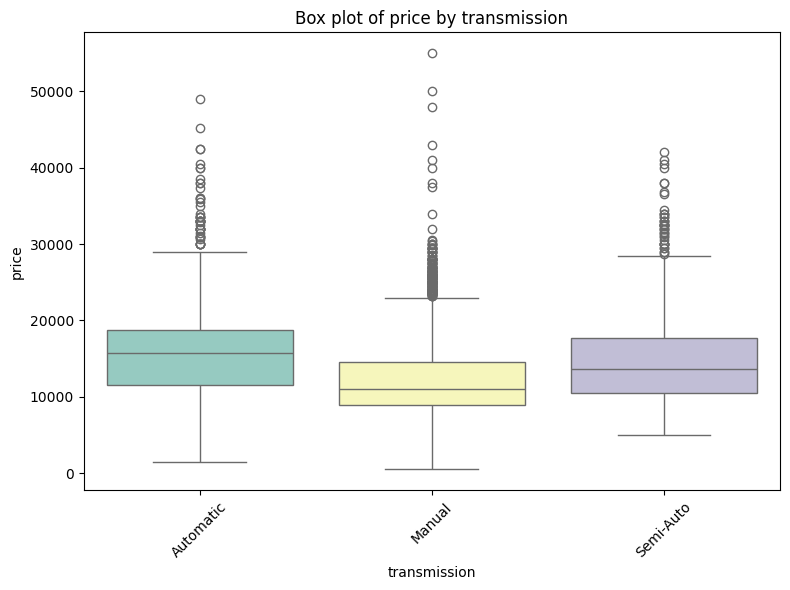

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")
def boxplot_between_attributes(df: pd.DataFrame, source_attr: str, target_attr: str,
                               bins: int = 10, rotate_x: int = 0,
                               figsize: tuple = (8, 6), save_path: str = None,
                               title: str = None) -> None:
    """
    Create a Seaborn box plot of target_attr by groups defined by source_attr.

    - If source_attr is numeric, it will be binned into 'bins' equal-width intervals.
    - If target_attr is non-numeric, it will be coerced to numeric (NaNs where coercion fails).

    Parameters:
    - df: input DataFrame
    - source_attr: column name to define groups (categorical or numeric)
    - target_attr: column name to plot on the y-axis (numeric)
    - bins: number of bins if source_attr is numeric
    - rotate_x: degrees to rotate x-axis labels (0 means no rotation)
    - figsize: figure size
    - save_path: if provided, save the plot to this path
    - title: optional plot title
    """
    if source_attr not in df.columns:
        raise ValueError(f"Source attribute '{source_attr}' not found in DataFrame.")
    if target_attr not in df.columns:
        raise ValueError(f"Target attribute '{target_attr}' not found in DataFrame.")

    plot_df = df.copy()

    # Ensure target is numeric
    if not pd.api.types.is_numeric_dtype(plot_df[target_attr]):
        plot_df[target_attr] = pd.to_numeric(plot_df[target_attr], errors='coerce')

    # If source is numeric, bin it; otherwise use as category
    if pd.api.types.is_numeric_dtype(plot_df[source_attr]):
        plot_df['_source_bin'] = pd.cut(plot_df[source_attr], bins=bins, include_lowest=True)
        x_col = '_source_bin'
        xlabel = f"{source_attr} (binned)"
    else:
        x_col = source_attr
        xlabel = source_attr

    plt.figure(figsize=figsize)
    sns.boxplot(x=x_col, y=target_attr, data=plot_df, palette="Set3")

    plt.xlabel(xlabel)
    plt.ylabel(target_attr)

    if title:
        plt.title(title)
    else:
        plt.title(f"Box plot of {target_attr} by {source_attr}")

    if rotate_x:
        plt.xticks(rotation=rotate_x)

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')

    plt.tight_layout()
    plt.show()

# Example usage:
df = pd.read_csv("dataset.csv")
boxplot_between_attributes(df, source_attr='transmission', target_attr='price', bins=8, rotate_x=45)

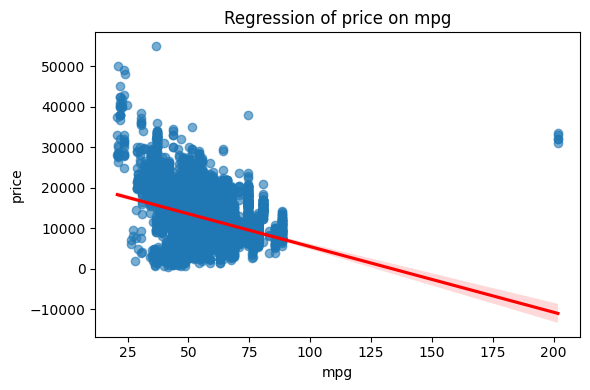

In [20]:
def regression_plot_between_attributes(
    df: pd.DataFrame,
    source_attr: str,
    target_attr: str,
    order: int = 1,
    scatter_kws: dict = None,
    line_kws: dict = None,
    figsize: tuple = (6, 4),
    save_path: str = None,
    title: str = None,
    show: bool = True
) -> None:
    """
    Create a regression plot of target_attr vs. source_attr using seaborn.regplot.

    - Converts both columns to numeric (coercing non-numeric values to NaN) and drops rows with NaN in either column.
    - 'order' controls the degree of the polynomial fit (default 1 for linear).
    - Optional scatter_kws and line_kws to customize the plot.
    - If save_path is provided, saves the plot to that path.
    - If show is True, displays the plot.

    Parameters:
    - df: input DataFrame
    - source_attr: column name for x-axis (numeric)
    - target_attr: column name for y-axis (numeric)
    - order: polynomial order for the fit (default 1)
    - scatter_kws: dict of keyword arguments for the scatter points
    - line_kws: dict of keyword arguments for the regression line
    - figsize: figure size
    - save_path: path to save the plot (optional)
    - title: optional plot title
    - show: whether to display the plot
    """
    if source_attr not in df.columns:
        raise ValueError(f"Source attribute '{source_attr}' not found in DataFrame.")
    if target_attr not in df.columns:
        raise ValueError(f"Target attribute '{target_attr}' not found in DataFrame.")

    # Work on a copy to avoid modifying the original DataFrame
    plot_df = df[[source_attr, target_attr]].copy()

    # Coerce to numeric
    plot_df[source_attr] = pd.to_numeric(plot_df[source_attr], errors='coerce')
    plot_df[target_attr] = pd.to_numeric(plot_df[target_attr], errors='coerce')

    # Drop rows with NaN in either column
    plot_df = plot_df.dropna(subset=[source_attr, target_attr])

    if plot_df.empty:
        raise ValueError("No valid numeric data available for the given attributes after cleaning.")

    if scatter_kws is None:
        scatter_kws = {'alpha': 0.6}

    if line_kws is None:
        line_kws = {'color': 'red'}

    plt.figure(figsize=figsize)
    ax = sns.regplot(
        x=source_attr,
        y=target_attr,
        data=plot_df,
        order=order,
        scatter_kws=scatter_kws,
        line_kws=line_kws
    )

    ax.set_xlabel(source_attr)
    ax.set_ylabel(target_attr)
    if title:
        ax.set_title(title)
    else:
        ax.set_title(f"Regression of {target_attr} on {source_attr}")

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')

    plt.tight_layout()
    if show:
        plt.show()
    else:
        plt.close()

# Example usage:
df = pd.read_csv("dataset.csv")
regression_plot_between_attributes(df, source_attr='mpg', target_attr='price', order=1)

In [22]:
import re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

def fit_linear_regression_and_evaluate(df: pd.DataFrame,
                                       source_attr: str,
                                       target_attr: str,
                                       test_size: float = 0.2,
                                       random_state: int = 42):
    """
    Fit a simple linear regression model: target_attr ~ source_attr.
    Returns a dict with model details and evaluation metrics.

    Parameters:
    - df: input DataFrame
    - source_attr: feature column name (X)
    - target_attr: target column name (y)
    - test_size: fraction of data to use as test set
    - random_state: seed for reproducibility
    """
    if source_attr not in df.columns or target_attr not in df.columns:
        raise ValueError("Specified columns must exist in the DataFrame.")

    # Prepare data: numeric conversion and drop rows with NaN in either column
    tmp = df[[source_attr, target_attr]].copy()
    tmp[source_attr] = pd.to_numeric(tmp[source_attr], errors='coerce')
    tmp[target_attr] = pd.to_numeric(tmp[target_attr], errors='coerce')
    tmp = tmp.dropna(subset=[source_attr, target_attr])

    if tmp.shape[0] < 2:
        raise ValueError("Not enough valid samples to fit the model.")

    X = tmp[[source_attr]].values
    y = tmp[target_attr].values

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Fit model
    reg = LinearRegression()
    reg.fit(X_train, y_train)

    # Predict
    y_pred_train = reg.predict(X_train)
    y_pred_test = reg.predict(X_test)

    # Metrics
    r2_train = r2_score(y_train, y_pred_train)
    mse_train = mean_squared_error(y_train, y_pred_train)

    r2_test = r2_score(y_test, y_pred_test)
    mse_test = mean_squared_error(y_test, y_pred_test)

    return {
        "model": reg,
        "coef": reg.coef_[0],
        "intercept": reg.intercept_,
        "r2_train": r2_train,
        "mse_train": mse_train,
        "r2_test": r2_test,
        "mse_test": mse_test,
        "n_train": len(X_train),
        "n_test": len(X_test),
        "n_total": len(X)
    }

# Example usage:
df = pd.read_csv("dataset.csv")
result = fit_linear_regression_and_evaluate(df, source_attr='mpg', target_attr='price', test_size=0.2)
print("Train R^2:", result["r2_train"])
print("Test R^2 :", result["r2_test"])
print("Train MSE:", result["mse_train"])
print("Test MSE :", result["mse_test"])

Train R^2: 0.11675061170401924
Test R^2 : 0.132520978401636
Train MSE: 19868134.620592922
Test MSE : 19441984.663323067


In [24]:
from typing import List, Optional, Dict, Any

def fit_linear_regression_multivariate_and_evaluate(
    df: pd.DataFrame,
    feature_cols: List[str],
    target_col: str,
    test_size: float = 0.2,
    random_state: int = 42,
    scale: bool = False
) -> Dict[str, Any]:
    """
    Fit a multivariate linear regression model: target_col ~ feature_cols.
    Returns a dict with model details and evaluation metrics.

    Parameters:
    - df: input DataFrame
    - feature_cols: list of feature column names (X)
    - target_col: target column name (y)
    - test_size: fraction of data to use as test set
    - random_state: seed for reproducibility
    - scale: if True, standardize features before regression

    Returns:
    - dict with keys:
      - 'model' or 'pipeline' (the fitted model),
      - 'coef' (coefficients for each feature, aligned with feature_cols),
      - 'intercept' (model intercept),
      - 'r2_train', 'mse_train', 'r2_test', 'mse_test',
      - 'n_train', 'n_test', 'n_total'
    """
    # Validate inputs
    if not isinstance(feature_cols, (list, tuple)) or len(feature_cols) == 0:
        raise ValueError("feature_cols must be a non-empty list of column names.")
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found in DataFrame.")
    for col in feature_cols:
        if col not in df.columns:
            raise ValueError(f"Feature column '{col}' not found in DataFrame.")

    # Prepare data: numeric conversion and drop rows with NaN in involved columns
    subset = df[feature_cols + [target_col]].copy()
    for col in feature_cols + [target_col]:
        subset[col] = pd.to_numeric(subset[col], errors='coerce')
    subset = subset.dropna()

    if subset.shape[0] < 2:
        raise ValueError("Not enough valid samples to fit the model.")

    X = subset[feature_cols].values
    y = subset[target_col].values

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    if scale:
        from sklearn.preprocessing import StandardScaler
        from sklearn.pipeline import Pipeline
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('reg', LinearRegression())
        ])
        pipeline.fit(X_train, y_train)
        y_pred_train = pipeline.predict(X_train)
        y_pred_test = pipeline.predict(X_test)

        coef = pipeline.named_steps['reg'].coef_
        intercept = pipeline.named_steps['reg'].intercept_
        model = pipeline
    else:
        reg = LinearRegression()
        reg.fit(X_train, y_train)
        y_pred_train = reg.predict(X_train)
        y_pred_test = reg.predict(X_test)

        coef = reg.coef_
        intercept = reg.intercept_
        model = reg

    # Metrics
    r2_train = r2_score(y_train, y_pred_train)
    mse_train = mean_squared_error(y_train, y_pred_train)

    r2_test = r2_score(y_test, y_pred_test)
    mse_test = mean_squared_error(y_test, y_pred_test)

    return {
        'model': model,
        'features': list(feature_cols),
        'target': target_col,
        'coef': list(np.asarray(coef).flatten()),
        'intercept': float(intercept),
        'r2_train': float(r2_train),
        'mse_train': float(mse_train),
        'r2_test': float(r2_test),
        'mse_test': float(mse_test),
        'n_train': int(len(X_train)),
        'n_test': int(len(X_test)),
        'n_total': int(len(X))
    }

# Example usage:
df = pd.read_csv("dataset.csv")
result = fit_linear_regression_multivariate_and_evaluate(
    df,
    feature_cols=['year', 'mileage', 'tax', 'engineSize'],
    target_col='price',
    test_size=0.2,
    random_state=42,
    scale=False  # set to True if you want to standardize features
)
print("Train R^2:", result["r2_train"])
print("Test R^2 :", result["r2_test"])
print("Train MSE:", result["mse_train"])
print("Test MSE :", result["mse_test"])

Train R^2: 0.7054220154392101
Test R^2 : 0.7081876964194234
Train MSE: 6607111.379699047
Test MSE : 6615174.261438221


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

def fit_poly2_linear_pipeline_and_evaluate(
    df: pd.DataFrame,
    feature_cols: list,
    target_col: str,
    test_size: float = 0.2,
    random_state: int = 42,
    degree: int = 2
) -> dict:
    """
    Create a pipeline with StandardScaler, PolynomialFeatures (degree=degree),
    and LinearRegression. Fit on the provided features to predict the target.
    Returns evaluation metrics (R^2 and MSE) for train and test sets.

    Parameters:
    - df: input DataFrame
    - feature_cols: list of feature column names to use as X
    - target_col: target column name to predict (y)
    - test_size: fraction of data to use as test set
    - random_state: seed for reproducibility
    - degree: degree of polynomial features (default 2)

    Returns:
    - A dictionary with:
      - 'pipeline': the fitted Pipeline object
      - 'coef': coefficients of the final linear regression (after expansion)
      - 'intercept': intercept of the final model
      - 'r2_train', 'mse_train', 'r2_test', 'mse_test'
      - 'n_train', 'n_test'
    """
    # Validate inputs
    for col in feature_cols:
        if col not in df.columns:
            raise ValueError(f"Feature column '{col}' not found in DataFrame.")
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found in DataFrame.")
    if len(feature_cols) == 0:
        raise ValueError("feature_cols must be a non-empty list.")

    # Prepare data: numeric conversion and drop rows with NaN in involved columns
    subset = df[feature_cols + [target_col]].copy()
    for col in feature_cols + [target_col]:
        subset[col] = pd.to_numeric(subset[col], errors='coerce')
    subset = subset.dropna()

    if subset.shape[0] < 2:
        raise ValueError("Not enough valid samples to fit the model.")

    X = subset[feature_cols].values
    y = subset[target_col].values

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Build the pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('reg', LinearRegression())
    ])

    # Fit
    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)

    # Metrics
    r2_train = r2_score(y_train, y_pred_train)
    mse_train = mean_squared_error(y_train, y_pred_train)

    r2_test = r2_score(y_test, y_pred_test)
    mse_test = mean_squared_error(y_test, y_pred_test)

    # Coefficients of the final linear model (after feature expansion)
    coef = pipeline.named_steps['reg'].coef_.tolist()
    intercept = float(pipeline.named_steps['reg'].intercept_)

    return {
        'pipeline': pipeline,
        'coef': coef,
        'intercept': intercept,
        'r2_train': float(r2_train),
        'mse_train': float(mse_train),
        'r2_test': float(r2_test),
        'mse_test': float(mse_test),
        'n_train': int(len(X_train)),
        'n_test': int(len(X_test))
    }

# Example usage:
df = pd.read_csv("dataset.csv")
result = fit_poly2_linear_pipeline_and_evaluate(
    df,
    feature_cols=['year', 'mileage', 'tax', 'engineSize'],
    target_col='price',
    test_size=0.2,
    random_state=42,
    degree=2
)
print("Train R^2:", result['r2_train'], "Train MSE:", result['mse_train'])
print("Test R^2 :", result['r2_test'], "Test MSE :", result['mse_test'])
print("Intercept:", result['intercept'])
print("Coefficients length:", len(result['coef']))

Train R^2: 0.7501975989201753 Train MSE: 5602836.509698703
Test R^2 : 0.7396570013172177 Test MSE : 5901787.837250804
Intercept: 11984.008465355553
Coefficients length: 14


In [30]:
from sklearn.linear_model import Ridge

def fit_ridge_and_evaluate(df: pd.DataFrame,
                           feature_cols: list,
                           target_col: str,
                           test_size: float = 0.2,
                           random_state: int = 42,
                           alpha: float = 0.1) -> dict:
    """
    Split data into train/test, fit a Ridge regression model (alpha=0.1 by default)
    using the given feature columns to predict the target column, and return
    evaluation metrics on the test set (MSE and R^2).

    Parameters:
    - df: input DataFrame
    - feature_cols: list of feature column names
    - target_col: target column name
    - test_size: fraction for the test set
    - random_state: seed for reproducibility
    - alpha: Ridge regularization strength
    """
    if not isinstance(feature_cols, (list, tuple)) or len(feature_cols) == 0:
        raise ValueError("feature_cols must be a non-empty list of column names.")
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found in DataFrame.")
    for col in feature_cols:
        if col not in df.columns:
            raise ValueError(f"Feature column '{col}' not found in DataFrame.")

    # Prepare data: numeric conversion and drop rows with NaN in involved columns
    subset = df[feature_cols + [target_col]].copy()
    for col in feature_cols + [target_col]:
        subset[col] = pd.to_numeric(subset[col], errors='coerce')
    subset = subset.dropna()

    if subset.shape[0] < 2:
        raise ValueError("Not enough valid samples to fit the model.")

    X = subset[feature_cols].values
    y = subset[target_col].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    y_pred_test = model.predict(X_test)

    mse_test = mean_squared_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)

    return {
        'model': model,
        'alpha': alpha,
        'r2_test': float(r2_test),
        'mse_test': float(mse_test),
        'n_train': int(len(X_train)),
        'n_test': int(len(X_test)),
        'n_total': int(len(X))
    }

# Example usage:
df = pd.read_csv("dataset.csv")
features = ['year', 'mileage', 'tax', 'engineSize']
target = 'price'
result = fit_ridge_and_evaluate(df, features, target, test_size=0.2, random_state=42, alpha=0.1)
print("Test R^2:", result['r2_test'])
print("Test MSE:", result['mse_test'])

Test R^2: 0.7081873687436668
Test MSE: 6615181.68961107


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

def fit_ridge_with_poly2_pipeline_and_evaluate(
    df: pd.DataFrame,
    feature_cols: list,
    target_col: str,
    test_size: float = 0.2,
    random_state: int = 42,
    alpha: float = 0.1
) -> dict:
    """
    Build a pipeline: PolynomialFeatures(degree=2) -> StandardScaler -> Ridge(alpha=0.1),
    fit on the given features to predict the target, and evaluate on the test set.

    Parameters:
    - df: input DataFrame
    - feature_cols: list of feature column names (source attributes)
    - target_col: target column name (the attribute to predict)
    - test_size: fraction of data to use as test set (default 0.2)
    - random_state: seed for reproducibility
    - alpha: Ridge regularization strength (default 0.1)

    Returns:
    - dict with keys:
      'pipeline': fitted Pipeline object
      'coef': coefficients of the final Ridge model (after polynomial expansion)
      'intercept': intercept of the Ridge model
      'r2_test': R^2 on the test set
      'mse_test': MSE on the test set
      'n_train': number of training samples
      'n_test': number of testing samples
      'n_total': total samples used
    """
    # Validate inputs
    if not isinstance(feature_cols, (list, tuple)) or len(feature_cols) == 0:
        raise ValueError("feature_cols must be a non-empty list of column names.")
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found in DataFrame.")
    for col in feature_cols:
        if col not in df.columns:
            raise ValueError(f"Feature column '{col}' not found in DataFrame.")

    # Prepare data: numeric conversion and drop rows with NaN in involved columns
    subset = df[feature_cols + [target_col]].copy()
    for col in feature_cols + [target_col]:
        subset[col] = pd.to_numeric(subset[col], errors='coerce')
    subset = subset.dropna()

    if subset.shape[0] < 2:
        raise ValueError("Not enough valid samples to fit the model.")

    X = subset[feature_cols].values
    y = subset[target_col].values

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Build the pipeline: degree-2 polynomial features, scaling, then ridge regression
    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])

    # Fit
    pipeline.fit(X_train, y_train)

    # Predictions on the test set
    y_pred_test = pipeline.predict(X_test)

    # Metrics on the test set
    mse_test = mean_squared_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)

    # Coefficients of the final model (after polynomial expansion)
    coef = pipeline.named_steps['ridge'].coef_.tolist()
    intercept = float(pipeline.named_steps['ridge'].intercept_)

    return {
        'pipeline': pipeline,
        'coef': coef,
        'intercept': intercept,
        'r2_test': float(r2_test),
        'mse_test': float(mse_test),
        'n_train': int(len(X_train)),
        'n_test': int(len(X_test)),
        'n_total': int(len(X))
    }

# Example usage:
df = pd.read_csv("dataset.csv")
features = ['year', 'mileage', 'tax', 'engineSize']  # source attributes
target = 'price'
result = fit_ridge_with_poly2_pipeline_and_evaluate(df, features, target, test_size=0.2, random_state=42, alpha=0.1)
print("Test R^2:", result['r2_test'])
print("Test MSE:", result['mse_test'])
print("Intercept:", result['intercept'])
print("Number of features after expansion (coef len):", len(result['coef']))


Test R^2: 0.728277945410232
Test MSE: 6159742.820065887
Intercept: 12259.251496171875
Number of features after expansion (coef len): 14


In [32]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

def fit_ridge_gridsearch_poly2_evaluate(
    df: pd.DataFrame,
    feature_cols: list,
    target_col: str,
    test_size: float = 0.2,
    random_state: int = 42,
    degree: int = 2,
    alpha_grid: list = None,
    cv: int = 5
) -> dict:
    """
    Split data into train/test, apply polynomial features (degree=2),
    scale, and fit a Ridge regression using a grid search with cross-validation
    to select the best alpha. Evaluate on the test set.

    Parameters:
    - df: input DataFrame
    - feature_cols: list of feature column names (source attributes)
    - target_col: target column name
    - test_size: fraction for the test set (default 0.2)
    - random_state: seed for reproducibility
    - degree: degree of polynomial features (default 2)
    - alpha_grid: list of Ridge alpha values to search (default [0.1, 1.0, 10.0, 100.0])
    - cv: number of cross-validation folds (default 5)

    Returns:
    - dict with keys:
      'grid': the fitted GridSearchCV object
      'pipeline': the best Pipeline after grid search
      'coef': coefficients of the final Ridge model (after polynomial expansion)
      'intercept': intercept of the Ridge model
      'best_alpha': selected alpha value
      'r2_test': R^2 on the test set
      'mse_test': MSE on the test set
      'n_train': number of training samples
      'n_test': number of testing samples
      'n_total': total samples used
    """
    if not isinstance(feature_cols, (list, tuple)) or len(feature_cols) == 0:
        raise ValueError("feature_cols must be a non-empty list of column names.")
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found in DataFrame.")
    for col in feature_cols:
        if col not in df.columns:
            raise ValueError(f"Feature column '{col}' not found in DataFrame.")

    # Prepare data: numeric conversion and drop rows with NaN in involved columns
    subset = df[feature_cols + [target_col]].copy()
    for col in feature_cols + [target_col]:
        subset[col] = pd.to_numeric(subset[col], errors='coerce')
    subset = subset.dropna()

    if subset.shape[0] < 2:
        raise ValueError("Not enough valid samples to fit the model.")

    X = subset[feature_cols].values
    y = subset[target_col].values

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Default alpha grid if not provided
    if alpha_grid is None:
        alpha_grid = [0.1, 1.0, 10.0, 100.0]

    # Build the pipeline: degree-2 polynomial features, scaling, then ridge regression
    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge())
    ])

    # Grid search over ridge alpha
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid={'ridge__alpha': alpha_grid},
        cv=cv,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_pipeline = grid.best_estimator_
    best_alpha = grid.best_params_.get('ridge__alpha', None)

    # Predictions on the test set
    y_pred_test = best_pipeline.predict(X_test)

    # Metrics on the test set
    mse_test = mean_squared_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)

    # Coefficients of the final model (after polynomial expansion)
    coef = best_pipeline.named_steps['ridge'].coef_.tolist()
    intercept = float(best_pipeline.named_steps['ridge'].intercept_)

    return {
        'grid': grid,
        'pipeline': best_pipeline,
        'coef': coef,
        'intercept': intercept,
        'best_alpha': best_alpha,
        'r2_test': float(r2_test),
        'mse_test': float(mse_test),
        'n_train': int(len(X_train)),
        'n_test': int(len(X_test)),
        'n_total': int(len(X))
    }

# Example usage:
df = pd.read_csv("dataset.csv")
features = ['year', 'mileage', 'tax', 'engineSize']  # subset of attributes as sources
target = 'price'
result = fit_ridge_gridsearch_poly2_evaluate(
    df, feature_cols=features, target_col=target,
    test_size=0.2, random_state=42, degree=2,
    alpha_grid=[0.1, 1.0, 10.0, 100.0], cv=5
)
print("Test R^2:", result['r2_test'])
print("Test MSE:", result['mse_test'])
print("Best alpha:", result['best_alpha'])

Test R^2: 0.72719345456265
Test MSE: 6184327.444681307
Best alpha: 10.0


## Authors


[Abhishek Gagneja](https://www.linkedin.com/in/abhishek-gagneja-23051987/)


## Change Log


|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2023-12-10|0.1|Abhishek Gagneja|Initial Draft created|


Copyright © 2023 IBM Corporation. All rights reserved.
